# Price Elasticity with PyMC

## Import packages

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
import pymc as pm

/Users/kirawei/Library/Mobile Documents/com~apple~CloudDocs/data-science/price-elasticity-pymc/.venv/lib/python3.10/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [183]:
# impport datasets
data = pd.read_csv('data/synthetic_dataset.csv')
product_elasticities_df = pd.read_csv('data/product_elasticities_df.csv')

## EDA

### Price vs. elasticity

In [60]:
rng = np.random.default_rng(seed=42)
### Price vs. Quantity - plot 6 products randomly selected from each state * brand combination
brand_choice = list(rng.choice(product_elasticities_df['product'].unique(),6, replace=False))
state_choice = product_elasticities_df['state'].unique()
product_list_choice = [i +' ('+ j + ')' for i in brand_choice for j in rng.choice(state_choice,1, replace=False)]

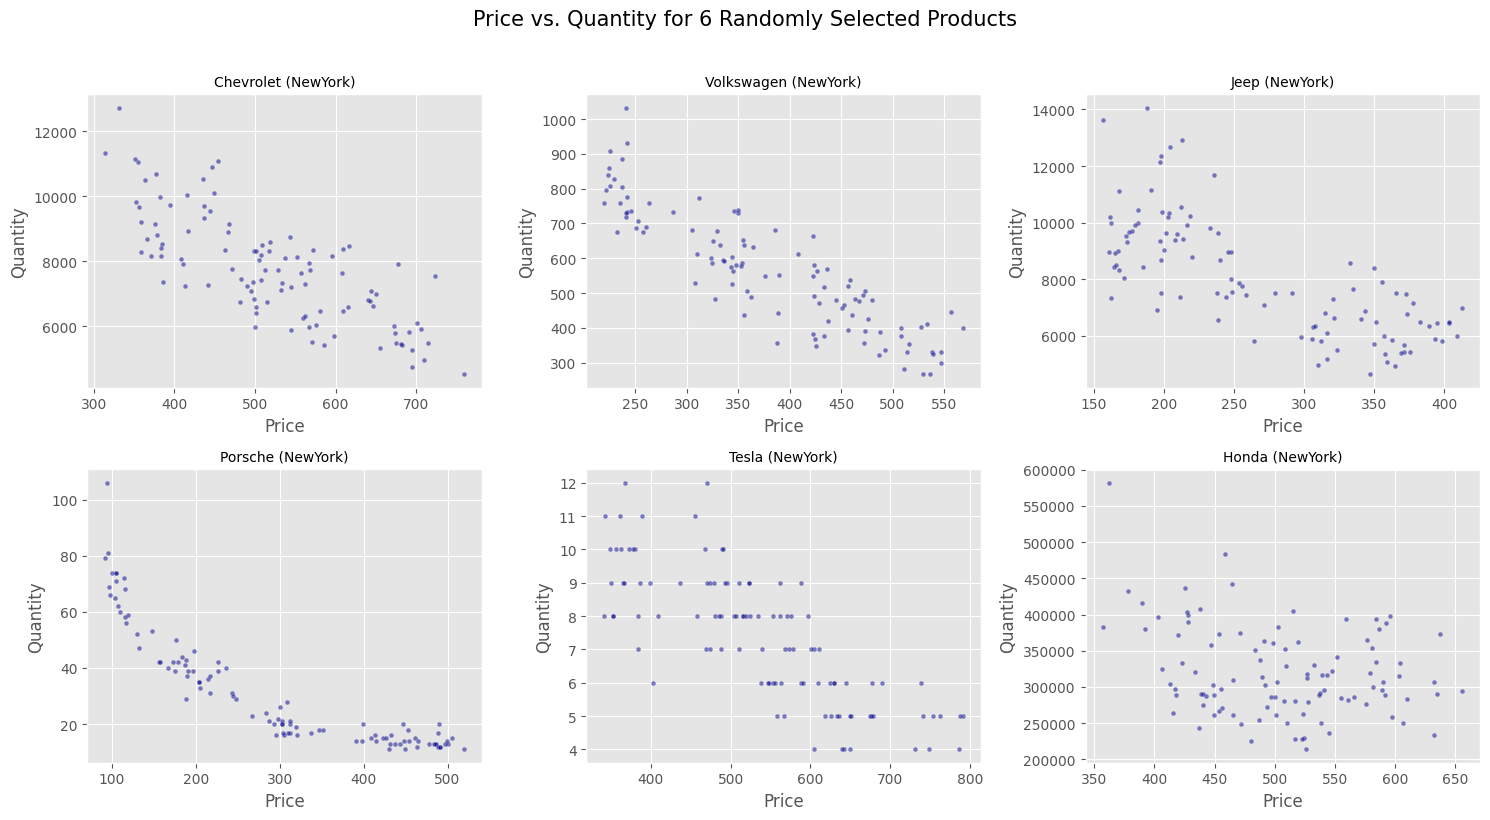

In [61]:
# scatter plot

plt.style.use('ggplot')
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=False, sharey=False)
for ax, product in zip(axes.flatten(), product_list_choice):
  sns.scatterplot(
  data = data.loc[data['product_id'] == product],
  x = 'price',
  y = 'quantity',
  ax = ax,
  alpha = 0.5,
  s=12,
  color = 'darkblue'
  )
  ax.set_xlabel('Price')
  ax.set_ylabel('Quantity')
  ax.set_title(product, fontsize=10)
plt.suptitle('Price vs. Quantity for 6 Randomly Selected Products', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('images/EDA/price_vs_quantity.png', bbox_inches='tight')

### Own elasticities vs. cross elasticities

In [126]:
# transform product elasticities dataframe to long format for plotting
product_elasticities_long_df = product_elasticities_df.melt(
  id_vars = ['category','state','product','elasticity','intercept'],
  var_name = 'paired_product',
  value_name = 'cross_elasticity'
)
# remove na
product_elasticities_long_df.dropna(axis=0, how='any', inplace=True)

# remove state from the paired product names
words_to_remove = [' (Florida)', ' (NewYork)']
for word in words_to_remove:
    product_elasticities_long_df['paired_product'] = product_elasticities_long_df['paired_product'].str.replace(word, '')
# save dataframe
product_elasticities_long_df.to_csv('data/product_elasticities_long_df.csv')

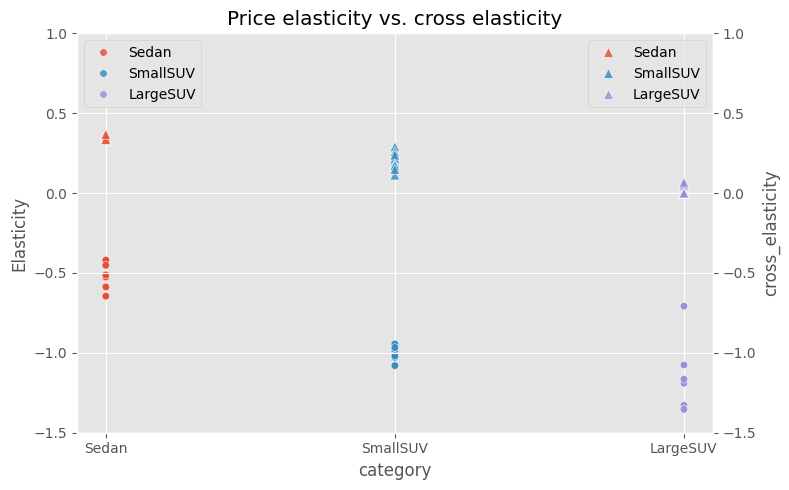

In [168]:
plt.style.use('ggplot')

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=product_elasticities_long_df,
    x='category',
    y='elasticity',
    hue='category',
    marker='o',
#    palette='Set1',
    s=30,
    alpha=0.8,
    ax = ax
)
ax.set_ylim(-1.5, 1)
ax.set_ylabel('Elasticity')
ax.legend(loc='upper left')
ax2 = ax.twinx()
sns.scatterplot(
    data=product_elasticities_long_df,
    x='category',
    y='cross_elasticity',
    hue='category',
    marker='^',
#    palette='Set1',
    s=50,
    alpha=0.8,
    ax = ax2
)
ax2.set_ylim(-1.5, 1)
ax2.legend(loc='upper right')
plt.title('Price elasticity vs. cross elasticity')
plt.tight_layout()
plt.savefig('images/EDA/elasticity_crosselasticity.png')

## Model

### No pooling

In [ ]:
# create a mapping of product_id to an index for use in the model
product_ids = sorted(data["product_id"].unique())
product_idx_map = {s: i for i, s in enumerate(product_ids)}
obs_product_idx = data["product_id"].map(product_idx_map).values

{'Chevrolet (Florida)': 0,
 'Chevrolet (NewYork)': 1,
 'Honda (Florida)': 2,
 'Honda (NewYork)': 3,
 'Hyundai (Florida)': 4,
 'Hyundai (NewYork)': 5,
 'Jeep (Florida)': 6,
 'Jeep (NewYork)': 7,
 'Mazda (Florida)': 8,
 'Mazda (NewYork)': 9,
 'Porsche (Florida)': 10,
 'Porsche (NewYork)': 11,
 'Tesla (Florida)': 12,
 'Tesla (NewYork)': 13,
 'Toyota (Florida)': 14,
 'Toyota (NewYork)': 15,
 'Volkswagen (Florida)': 16,
 'Volkswagen (NewYork)': 17}

In [ ]:

# Label the dimension of model variables with the name of the coordinate, which is "product_id" in this case.
coords = {
    'product_id': data['product_id'].unique()
}

with pm.Model(coords=coords) as no_pooling_model:
    # Intercept to baseline demand
    alpha = pm.Normal("alpha", mu=10, sigma=2.0, dims="product_id")
    # Prior of overall elasticity mean across all products
    mu_elasticity = pm.LogNormal('mu_elasticity', mu=-1, sigma=0.5, dims='product_id')

    # Additive seasonality effect on elasticity mean
    beta_season = pm.Normal('beta_season', mu=0, sigma=0.5) # Can be positive or negative

    # Add standard deviation for the elasticity distributions
    sigma = pm.HalfNormal('sigma', sigma=0.5)

    # Define the expectted log-quantity
    mu = (
        alpha[obs_product_idx] # use index due to tensor indexing requiring integers
        + mu_elasticity[obs_product_idx] * data["log_price"].values
        + beta_season * data["seasonality"].values
        )

    # Define the Bayesian model, connecting model's predictions to the actual data
    pm.Normal("obs", mu=mu, sigma=sigma, observed=data["log_quantity"].values)

    # Run MCMC sampling to approximate the posterior distribution
    trace_basic = pm.sample(
            1000, # sample size
            tune=1000,  # tune-steps
            chains=2, # 2 independent chains
            cores=1,
            random_seed=42, progressbar=True,
            target_accept=0.9, # smaller step
        )

,week,product_id,product,category,state,price,quantity,log_price,log_quantity,seasonality
0,0,Honda (Florida),Honda,Sedan,Florida,222.96,262810,5.4070,12.4792,0.0000
1,1,Honda (Florida),Honda,Sedan,Florida,224.56,261452,5.4141,12.4740,0.1205
2,2,Honda (Florida),Honda,Sedan,Florida,232.45,248932,5.4487,12.4249,0.2393
3,3,Honda (Florida),Honda,Sedan,Florida,227.53,288255,5.4273,12.5716,0.3546
4,4,Honda (Florida),Honda,Sedan,Florida,229.34,282239,5.4352,12.5505,0.4647
...,...,...,...,...,...,...,...,...,...,...
1867,99,Porsche (NewYork),Porsche,LargeSUV,NewYork,98.18,66,4.5868,4.1897,-0.5681
1868,100,Porsche (NewYork),Porsche,LargeSUV,NewYork,96.78,69,4.5724,4.2341,-0.4647
1869,101,Porsche (NewYork),Porsche,LargeSUV,NewYork,93.99,106,4.5431,4.6634,-0.3546
1870,102,Porsche (NewYork),Porsche,LargeSUV,NewYork,94.76,81,4.5514,4.3944,-0.2393


In [178]:
pd.concat([data[data['product_id'] == 'Hyundai (Florida)'].head(10),
       data[data['product_id'] == 'Honda (Florida)'].head(10)
])

,week,product_id,product,category,state,price,quantity,log_price,log_quantity,seasonality
208,0,Hyundai (Florida),Hyundai,Sedan,Florida,463.48,384618,6.1388,12.8600,0.0000
209,1,Hyundai (Florida),Hyundai,Sedan,Florida,438.45,393849,6.0833,12.8837,0.1205
210,2,Hyundai (Florida),Hyundai,Sedan,Florida,428.24,460274,6.0597,13.0396,0.2393
211,3,Hyundai (Florida),Hyundai,Sedan,Florida,433.92,399309,6.0729,12.8975,0.3546
212,4,Hyundai (Florida),Hyundai,Sedan,Florida,435.06,486674,6.0755,13.0953,0.4647
213,5,Hyundai (Florida),Hyundai,Sedan,Florida,428.75,470601,6.0609,13.0618,0.5681
214,6,Hyundai (Florida),Hyundai,Sedan,Florida,426.54,488094,6.0557,13.0983,0.6631
215,7,Hyundai (Florida),Hyundai,Sedan,Florida,421.20,516766,6.0431,13.1553,0.7485
216,8,Hyundai (Florida),Hyundai,Sedan,Florida,424.42,528134,6.0507,13.1771,0.8230
217,9,Hyundai (Florida),Hyundai,Sedan,Florida,456.83,443404,6.1243,13.0022,0.8855
